# Fase 5: Clustering

Partimos de `data/processed/features_repos.parquet` (77,696 repos, Fase 4) y
aplicamos **KMeans** (no supervisado) para agrupar repos por comportamiento.

Pasos:
1. Armar el vector final de features: numericos escalados (7 columnas) +
   TF-IDF de texto (300 columnas).
2. Probar varios valores de k (numero de clusters) y comparar con dos
   metricas: costo (WSSSE, metodo del codo) y Silhouette. No asumimos un k
   de entrada — se elige mirando los resultados.
3. Entrenar el modelo final con el k elegido y guardar las asignaciones de
   cluster por repo, listas para interpretar en la Fase 6.

Usamos KMeans normal (no Bisecting) por ser el mas simple de explicar; el
proyecto permitia cualquiera de los dos.

In [1]:
from pyspark.sql import SparkSession

SEED = 42

spark = (SparkSession.builder
         .master("local[*]")
         .appName("clustering-gharchive")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

gold = spark.read.parquet("../data/processed/features_repos.parquet")
print("repos:", gold.count())
gold.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 21:49:56 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 21:49:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 21:49:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 77696
root
 |-- repo: string (nullable = true)
 |-- n_push: long (nullable = true)
 |-- n_issues: long (nullable = true)
 |-- n_pr: long (nullable = true)
 |-- n_watch: long (nullable = true)
 |-- n_fork: long (nullable = true)
 |-- n_total: long (nullable = true)
 |-- n_actores: long (nullable = true)
 |-- tfidf: vector (nullable = true)



## Paso 1a: transformar los conteos con log(1+x)

Al revisar los datos, los conteos de actividad estan muy sesgados: la
mediana de `n_push` es 3, pero el maximo es 2358 (un repo con actividad
masiva en esa hora). Sin corregir esto, unos pocos repos extremos jalan
tanto a KMeans que terminan solos en su propio cluster y todos los demas
77,691 repos caen juntos en uno solo — no es un agrupamiento util.

La solucion estandar para conteos con esta forma (pocos valores enormes,
la mayoria chicos) es aplicar `log(1 + x)`: comprime los valores extremos
sin cambiar el orden, y deja que `StandardScaler` funcione bien despues.

In [2]:
from pyspark.sql.functions import col, log, lit

cols_numericas = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total", "n_actores"]
cols_log = [f"{c}_log" for c in cols_numericas]

for c in cols_numericas:
    gold = gold.withColumn(f"{c}_log", log(col(c) + lit(1.0)))

gold.select(cols_numericas + cols_log).show(5)

+------+--------+----+-------+------+-------+---------+------------------+------------+------------------+-----------+----------+------------------+------------------+
|n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|        n_push_log|n_issues_log|          n_pr_log|n_watch_log|n_fork_log|       n_total_log|     n_actores_log|
+------+--------+----+-------+------+-------+---------+------------------+------------+------------------+-----------+----------+------------------+------------------+
|     3|       0|   0|      0|     0|      3|        1|1.3862943611198906|         0.0|               0.0|        0.0|       0.0|1.3862943611198906|0.6931471805599453|
|     4|       0|   0|      0|     0|      4|        1|1.6094379124341003|         0.0|               0.0|        0.0|       0.0|1.6094379124341003|0.6931471805599453|
|     4|       0|   0|      0|     0|      4|        1|1.6094379124341003|         0.0|               0.0|        0.0|       0.0|1.6094379124341003|0.6931471805

## Paso 1: armar el vector de features

Escalamos los numericos (`StandardScaler`) porque estan en escalas muy
distintas (ej. `n_push` puede llegar a cientos, `n_actores` casi siempre es
chico) — sin escalar, KMeans (que usa distancia euclidiana) le daria mas
peso a las columnas con numeros mas grandes solo por eso, no porque sean
mas importantes.

Tambien normalizamos el vector TF-IDF (`Normalizer`, longitud 1). Al
revisar los datos encontramos repos con texto repetido muchisimas veces
(ej. un repo con miles de commits casi identicos, posiblemente para inflar
su historial) — eso les da una magnitud de TF-IDF enorme (hasta 2.36e8,
contra 0 en el 75% de los repos que no tienen texto). Sin normalizar, esos
pocos repos dominarian el clustering solo por tener mucho texto repetido,
no por su comportamiento real.

In [3]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, Normalizer

ensamblar_numericos = VectorAssembler(inputCols=cols_log, outputCol="numericos_vec")
escalar_numericos = StandardScaler(inputCol="numericos_vec", outputCol="numericos_escalados",
                                    withMean=True, withStd=True)
normalizar_texto = Normalizer(inputCol="tfidf", outputCol="tfidf_norm", p=2.0)
ensamblar_final = VectorAssembler(inputCols=["numericos_escalados", "tfidf_norm"], outputCol="features")

pipeline_features = Pipeline(stages=[ensamblar_numericos, escalar_numericos, normalizar_texto, ensamblar_final])
modelo_features = pipeline_features.fit(gold)
datos = modelo_features.transform(gold).select("repo", *cols_numericas, "features")

datos.select("repo", "features").show(3, truncate=80)

+---------------------------------+--------------------------------------------------------------------------------+
|                             repo|                                                                        features|
+---------------------------------+--------------------------------------------------------------------------------+
|      0nenessPC/darer-journey-app|(307,[0,1,2,3,4,5,6],[-0.3116042464129336,-0.21853497373386127,-0.42744689119...|
|0xKhan-web3/0xKhan-web3.github.io|(307,[0,1,2,3,4,5,6],[-0.004751301571869301,-0.21853497373386127,-0.427446891...|
|                  0xb-s/egui_plot|(307,[0,1,2,3,4,5,6],[-0.004751301571869301,-0.21853497373386127,-0.427446891...|
+---------------------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [4]:
# Guardamos en cache porque vamos a entrenar KMeans varias veces sobre
# los mismos datos (uno por cada valor de k que probemos)
datos = datos.cache()
datos.count()

77696

## Paso 2: probar varios valores de k

No asumimos de entrada cuantos clusters usar. Probamos k de 2 a 10 y
medimos dos cosas para cada uno:

- **Costo (WSSSE)**: que tan lejos estan los puntos de su centroide. Baja
  siempre que aumenta k, buscamos donde deja de bajar tan fuerte ("el codo").
- **Silhouette**: que tan bien separados estan los clusters (va de -1 a 1,
  mas alto es mejor). Mas facil de explicar en la sustentacion que el codo.

In [5]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")

valores_k = range(2, 11)
resultados = []

for k in valores_k:
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=SEED)
    modelo = kmeans.fit(datos)
    predicciones = modelo.transform(datos)

    costo = modelo.summary.trainingCost
    silhouette = evaluador.evaluate(predicciones)

    resultados.append((k, costo, silhouette))
    print(f"k={k:2d}  costo={costo:,.1f}  silhouette={silhouette:.4f}")

k= 2  costo=468,140.4  silhouette=0.7557


k= 3  costo=361,521.8  silhouette=0.7486


k= 4  costo=306,253.6  silhouette=0.7514


k= 5  costo=240,769.4  silhouette=0.6663


k= 6  costo=201,071.7  silhouette=0.6829


k= 7  costo=213,629.1  silhouette=0.6800


k= 8  costo=171,405.7  silhouette=0.6979


k= 9  costo=165,464.9  silhouette=0.7000


k=10  costo=144,889.1  silhouette=0.5348


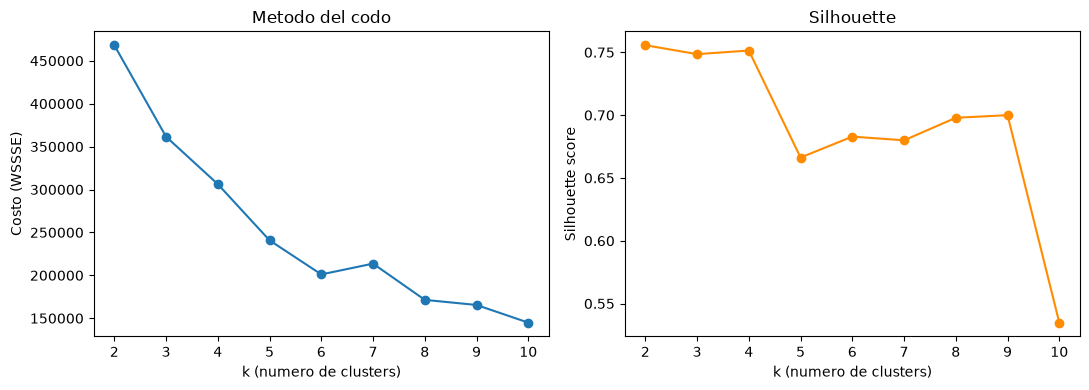

In [6]:
import matplotlib.pyplot as plt

ks = [r[0] for r in resultados]
costos = [r[1] for r in resultados]
silhouettes = [r[2] for r in resultados]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(ks, costos, marker="o")
ax1.set_title("Metodo del codo")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Costo (WSSSE)")

ax2.plot(ks, silhouettes, marker="o", color="darkorange")
ax2.set_title("Silhouette")
ax2.set_xlabel("k (numero de clusters)")
ax2.set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

## Paso 3: modelo final con k=3

Se eligio k=3 junto con el usuario: el silhouette (0.7486) es practicamente
igual al mejor puntaje (k=2, 0.7557), y encaja directo con la idea del
proyecto de agrupar repos en 3 niveles de salud (saludable / en riesgo /
abandonado) — la interpretacion real de cada cluster se hace en la Fase 6,
mirando los centroides.

In [7]:
K_FINAL = 3

kmeans_final = KMeans(featuresCol="features", predictionCol="cluster", k=K_FINAL, seed=SEED)
modelo_final = kmeans_final.fit(datos)
predicciones = modelo_final.transform(datos)

print("tamano de cada cluster:")
predicciones.groupBy("cluster").count().orderBy("cluster").show()

print("promedios (sin escalar) por cluster, para una primera idea:")
predicciones.groupBy("cluster").avg(*cols_numericas).orderBy("cluster").show()

tamano de cada cluster:
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 2189|
|      1|70295|
|      2| 5212|
+-------+-----+

promedios (sin escalar) por cluster, para una primera idea:


+-------+------------------+-------------------+-------------------+--------------------+--------------------+-----------------+------------------+
|cluster|       avg(n_push)|      avg(n_issues)|          avg(n_pr)|        avg(n_watch)|         avg(n_fork)|     avg(n_total)|    avg(n_actores)|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+-----------------+------------------+
|      0|2.9191411603471904|   1.02603928734582| 1.2718136135221563|  3.8396528095020557|  0.6706258565555048|9.727272727272727|6.7779808131566925|
|      1| 3.821936126324774|0.18836332598335587|0.36346824098442276|0.010086065865282027|7.539654313962587E-4|4.384607724589231|1.1845934988263747|
|      2| 60.43879508825787| 0.5775134305448963| 0.7939370683039141|0.003453568687643...|7.674597083653108E-4|61.81446661550269|1.3720260936300843|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+--

## Paso 4: guardar resultados

Guardamos:
- La tabla de repos con su cluster asignado, en
  `data/processed/repos_clusterizados.parquet`.
- El pipeline de features (escalado + normalizado) y el modelo KMeans
  entrenado, en `models/`, para poder reutilizarlos en la Fase 6 sin tener
  que reentrenar.

In [8]:
RUTA_RESULTADOS = "../data/processed/repos_clusterizados.parquet"
RUTA_PIPELINE_FEATURES = "../models/pipeline_features"
RUTA_MODELO_KMEANS = "../models/kmeans_final"

predicciones.select("repo", *cols_numericas, "cluster").write.mode("overwrite").parquet(RUTA_RESULTADOS)
modelo_features.write().overwrite().save(RUTA_PIPELINE_FEATURES)
modelo_final.write().overwrite().save(RUTA_MODELO_KMEANS)

verificacion = spark.read.parquet(RUTA_RESULTADOS)
print("filas guardadas:", verificacion.count())

filas guardadas: 77696
